In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

train_df = pd.read_csv("../splits/train.csv")
val_df = pd.read_csv("../splits/val.csv")

print("Training images:", len(train_df))
print("Validation images:", len(val_df))

Training images: 8017
Validation images: 1998


In [2]:
class_counts = train_df["dx"].value_counts().sort_index()

print("Training class distribution:\n")
print(class_counts)

Training class distribution:

dx
akiec     257
bcc       412
bkl       891
df         86
mel       890
nv       5367
vasc      114
Name: count, dtype: int64


In [3]:
class_percentages = (
    train_df["dx"]
    .value_counts(normalize=True)
    .sort_index()
    * 100
)

print(class_percentages.round(2))

dx
akiec     3.21
bcc       5.14
bkl      11.11
df        1.07
mel      11.10
nv       66.95
vasc      1.42
Name: proportion, dtype: float64


In [4]:
majority_class = class_counts.idxmax()
minority_class = class_counts.idxmin()

imbalance_ratio = (
    class_counts.max() /
    class_counts.min()
)

print("Majority class:", majority_class)
print("Minority class:", minority_class)
print("Imbalance ratio:", round(imbalance_ratio, 2))

Majority class: nv
Minority class: df
Imbalance ratio: 62.41


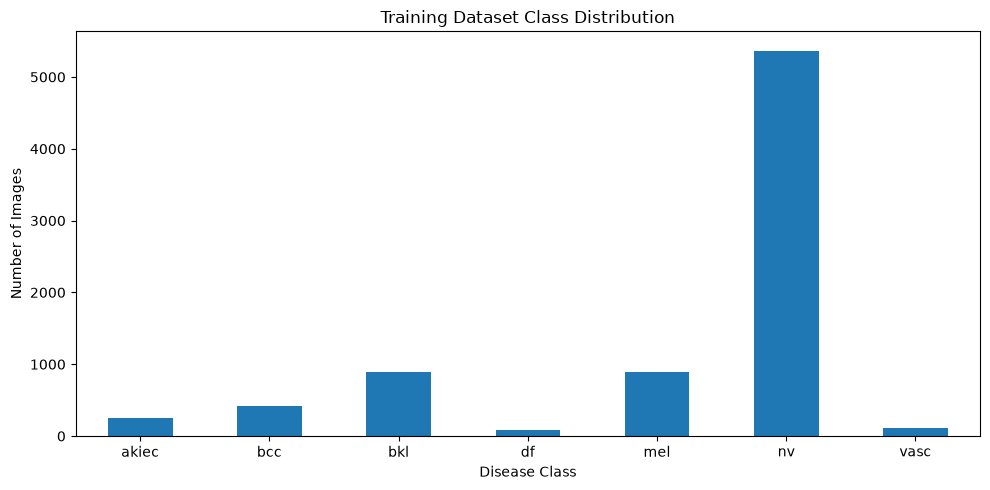

In [5]:
plt.figure(figsize=(10, 5))

class_counts.plot(kind="bar")

plt.title("Training Dataset Class Distribution")
plt.xlabel("Disease Class")
plt.ylabel("Number of Images")

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

Calculate Class Weights

We will use:

wi=n / c x ni
	​


Where:

N = total training images
C = number of classes
n
i
	​

 = images in class i

In [6]:
from sklearn.utils.class_weight import compute_class_weight

classes = np.array(
    sorted(train_df["dx"].unique())
)

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=train_df["dx"]
)

class_weights_dict = dict(
    zip(classes, class_weights)
)

print("Class Weights:\n")

for cls, weight in class_weights_dict.items():
    print(f"{cls}: {weight:.4f}")

Class Weights:

akiec: 4.4564
bcc: 2.7798
bkl: 1.2854
df: 13.3173
mel: 1.2868
nv: 0.2134
vasc: 10.0464


In [7]:
weights_df = pd.DataFrame({
    "Class": classes,
    "Image_Count": [
        class_counts[cls]
        for cls in classes
    ],
    "Percentage": [
        class_percentages[cls]
        for cls in classes
    ],
    "Class_Weight": class_weights
})

weights_df["Percentage"] = (
    weights_df["Percentage"].round(2)
)

weights_df["Class_Weight"] = (
    weights_df["Class_Weight"].round(4)
)

print(weights_df)

   Class  Image_Count  Percentage  Class_Weight
0  akiec          257        3.21        4.4564
1    bcc          412        5.14        2.7798
2    bkl          891       11.11        1.2854
3     df           86        1.07       13.3173
4    mel          890       11.10        1.2868
5     nv         5367       66.95        0.2134
6   vasc          114        1.42       10.0464


In [8]:
weights_df.to_csv(
    "../splits/class_weights.csv",
    index=False
)

print("Class weights saved successfully!")

Class weights saved successfully!
